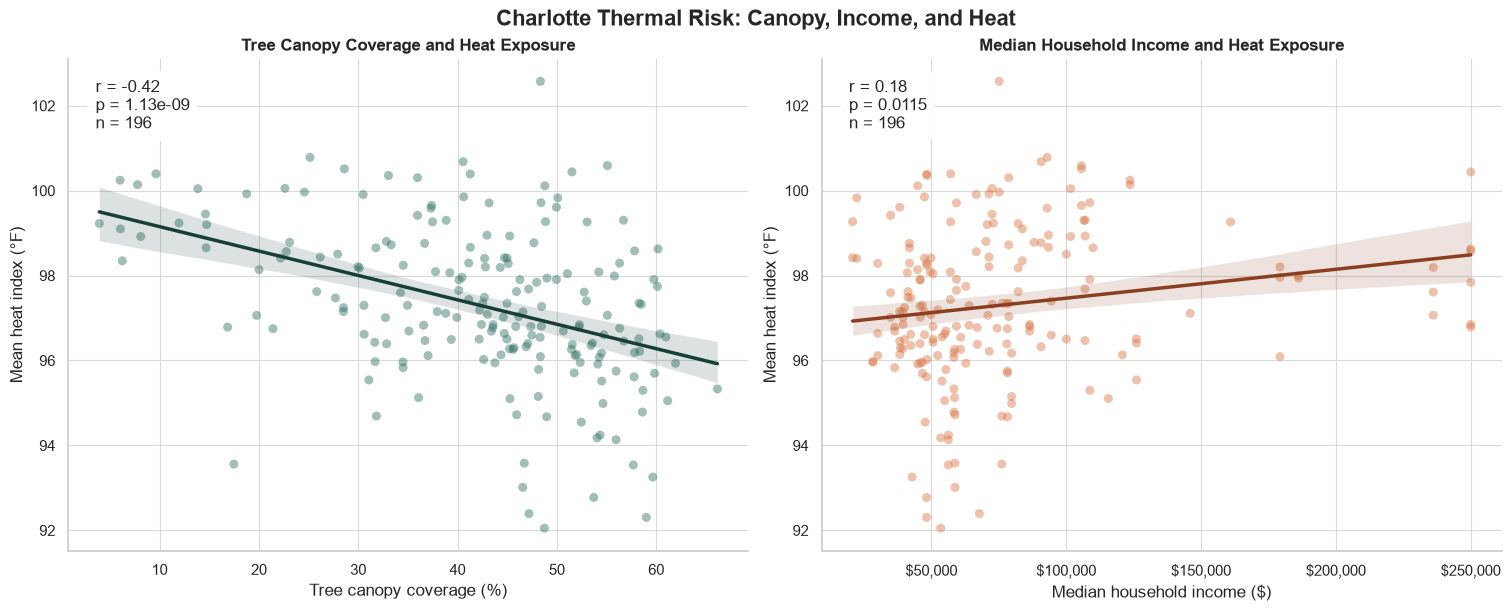

In [55]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns
from scipy import stats

PROJECT_DIR = Path(
    r"C:\Users\Fiorella\OneDrive\VSCODE PROJECTS\Projects\DTSC 2\Personal Project Part 1"
)
processed_file = (
    PROJECT_DIR
    / "notebooks"
    / "data"
    / "processed"
    / "charlotte_analysis.geojson"
)
gdf_analysis = gpd.read_file(processed_file, engine="pyogrio")

sns.set_theme(style="whitegrid", context="notebook")
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

canopy_heat = gdf_analysis.dropna(
    subset=["canopy_pct_2022", "mean_heat_index"]
)
sns.regplot(
    data=canopy_heat,
    x="canopy_pct_2022",
    y="mean_heat_index",
    ax=axes[0],
    color="#2f6f62",
    scatter_kws={"alpha": 0.45, "s": 42, "edgecolor": "none"},
    line_kws={"color": "#173f38", "linewidth": 2.5},
)
r1, p1 = stats.pearsonr(
    canopy_heat["canopy_pct_2022"], canopy_heat["mean_heat_index"]
)
axes[0].set_title("Tree Canopy Coverage and Heat Exposure", fontweight="bold")
axes[0].set_xlabel("Tree canopy coverage (%)")
axes[0].set_ylabel("Mean heat index (°F)")
axes[0].text(
    0.04,
    0.96,
    f"r = {r1:.2f}\np = {p1:.3g}\nn = {len(canopy_heat)}",
    transform=axes[0].transAxes,
    va="top",
    bbox={"boxstyle": "round,pad=0.45", "facecolor": "white", "alpha": 0.9},
)

income_heat = gdf_analysis.dropna(
    subset=["median_income", "mean_heat_index"]
)
sns.regplot(
    data=income_heat,
    x="median_income",
    y="mean_heat_index",
    ax=axes[1],
    color="#d97745",
    scatter_kws={"alpha": 0.45, "s": 42, "edgecolor": "none"},
    line_kws={"color": "#8c3f20", "linewidth": 2.5},
)
r2, p2 = stats.pearsonr(
    income_heat["median_income"], income_heat["mean_heat_index"]
)
axes[1].set_title("Median Household Income and Heat Exposure", fontweight="bold")
axes[1].set_xlabel("Median household income ($)")
axes[1].set_ylabel("Mean heat index (°F)")
axes[1].xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
axes[1].text(
    0.04,
    0.96,
    f"r = {r2:.2f}\np = {p2:.3g}\nn = {len(income_heat)}",
    transform=axes[1].transAxes,
    va="top",
    bbox={"boxstyle": "round,pad=0.45", "facecolor": "white", "alpha": 0.9},
)

for axis in axes:
    axis.grid(color="#d9d9d9", linewidth=0.8)
    sns.despine(ax=axis)

fig.suptitle(
    "Charlotte Thermal Risk: Canopy, Income, and Heat",
    fontsize=16,
    fontweight="bold",
)
plt.show()

In [56]:
import pandas as pd

# Prepare the full dataset and the block groups with observed heat values.
gdf_full = gdf_analysis.copy()
gdf_heat = gdf_analysis[
    gdf_analysis["mean_heat_index"].notna()
].copy()

canopy_tertiles = gdf_heat["canopy_pct_2022"].quantile([0.333, 0.667]).values
heat_tertiles = gdf_heat["mean_heat_index"].quantile([0.333, 0.667]).values

print(
    f"Canopy tertile cuts: {canopy_tertiles[0]:.1f}%, "
    f"{canopy_tertiles[1]:.1f}%"
)
print(
    f"Heat tertile cuts: {heat_tertiles[0]:.1f}F, "
    f"{heat_tertiles[1]:.1f}F"
)

def canopy_tier(value):
    if pd.isna(value):
        return None
    if value <= canopy_tertiles[0]:
        return "low"
    if value <= canopy_tertiles[1]:
        return "mid"
    return "high"


def heat_tier(value):
    if pd.isna(value):
        return None
    if value <= heat_tertiles[0]:
        return "low"
    if value <= heat_tertiles[1]:
        return "mid"
    return "high"


gdf_full["canopy_tier"] = gdf_full["canopy_pct_2022"].apply(canopy_tier)
gdf_full["heat_tier"] = gdf_full["mean_heat_index"].apply(heat_tier)
gdf_full["bivariate"] = gdf_full.apply(
    lambda row: (
        f"{row['canopy_tier']}_canopy_{row['heat_tier']}_heat"
        if pd.notna(row["heat_tier"])
        else "no_heat_data"
    ),
    axis=1,
)

bivariate_colors = {
    "low_canopy_high_heat": "#8b1a1a",
    "low_canopy_mid_heat": "#c0392b",
    "low_canopy_low_heat": "#e57373",
    "mid_canopy_high_heat": "#7b5ea7",
    "mid_canopy_mid_heat": "#a89cc8",
    "mid_canopy_low_heat": "#c8b4e3",
    "high_canopy_high_heat": "#2d6a4f",
    "high_canopy_mid_heat": "#52b788",
    "high_canopy_low_heat": "#b7e4c7",
    "no_heat_data": "#d9d9d9",
}

gdf_full["biv_color"] = gdf_full["bivariate"].map(bivariate_colors)
print("Bivariate category counts:")
print(gdf_full["bivariate"].value_counts())

Canopy tertile cuts: 38.8%, 48.5%
Heat tertile cuts: 96.5F, 98.1F
Bivariate category counts:
bivariate
no_heat_data             428
low_canopy_high_heat      36
high_canopy_low_heat      35
mid_canopy_mid_heat       29
mid_canopy_low_heat       19
high_canopy_mid_heat      19
low_canopy_mid_heat       18
mid_canopy_high_heat      18
low_canopy_low_heat       11
high_canopy_high_heat     11
Name: count, dtype: int64


In [57]:
neighborhood_crosswalk = {
    '15':  'Uptown',
    '16':  'First Ward',
    '17':  'Second Ward',
    '18':  'Third Ward',
    '19':  'Fourth Ward',
    '80':  'South End',
    '82':  'Brookhill',
    '86':  'Enderly Park',
    '88':  'Hoskins',
    '94':  'Hidden Valley',
    '96':  'Druid Hills',
    '123': 'Plaza Midwood',
    '127': 'Windsor Park',
    '139': 'NoDa',
    '167': 'Eastland',
    '246': 'University City',
    '325': 'Myers Park',
    '326': 'Eastover',
    '328': 'Foxcroft',
}

if 'NPA_ID' in gdf_full.columns:
    gdf_full['neighborhood_name'] = gdf_full['NPA_ID'].astype(str).map(neighborhood_crosswalk)
else:
    gdf_full['neighborhood_name'] = None
    print('WARNING: NPA_ID not found. Run NPA spatial join in data_cleaning.ipynb first.')

named = gdf_full[gdf_full['neighborhood_name'].notna()].copy()
print(f'Block groups with named neighborhood: {len(named)}')

Block groups with named neighborhood: 27


In [58]:
if len(named) > 0:
    neighborhood_polys = named.dissolve(by='neighborhood_name').reset_index()
    nbhd_stats = named.groupby('neighborhood_name').agg(
        median_canopy  = ('canopy_pct_2022', 'median'),
        median_heat    = ('mean_heat_index', 'median'),
        median_income  = ('median_income', 'median'),
        n_block_groups = ('GEOID_bg', 'count'),
    ).reset_index()
    neighborhood_polys = neighborhood_polys[['neighborhood_name', 'geometry']].merge(
        nbhd_stats, on='neighborhood_name'
    )
    print(neighborhood_polys[['neighborhood_name', 'median_canopy', 'median_heat', 'median_income']].to_string())

   neighborhood_name  median_canopy  median_heat  median_income
0          Brookhill         34.370          NaN        82375.0
1        Druid Hills         42.090          NaN        80280.0
2           Eastland         48.740    92.050575        53438.0
3           Eastover         46.150    97.032203        78672.0
4       Enderly Park         41.130    97.436000        57004.0
5         First Ward         60.105    96.160921        50775.5
6        Fourth Ward         57.485          NaN       103750.0
7           Foxcroft         43.540    96.776786        66994.0
8      Hidden Valley         42.290          NaN        42359.0
9            Hoskins         39.920    97.013596        34849.0
10        Myers Park         66.450          NaN        67808.0
11              NoDa         53.170          NaN        48337.0
12     Plaza Midwood         42.620    96.022881        48337.0
13       Second Ward         49.405    96.241118        55373.0
14         South End         56.030     

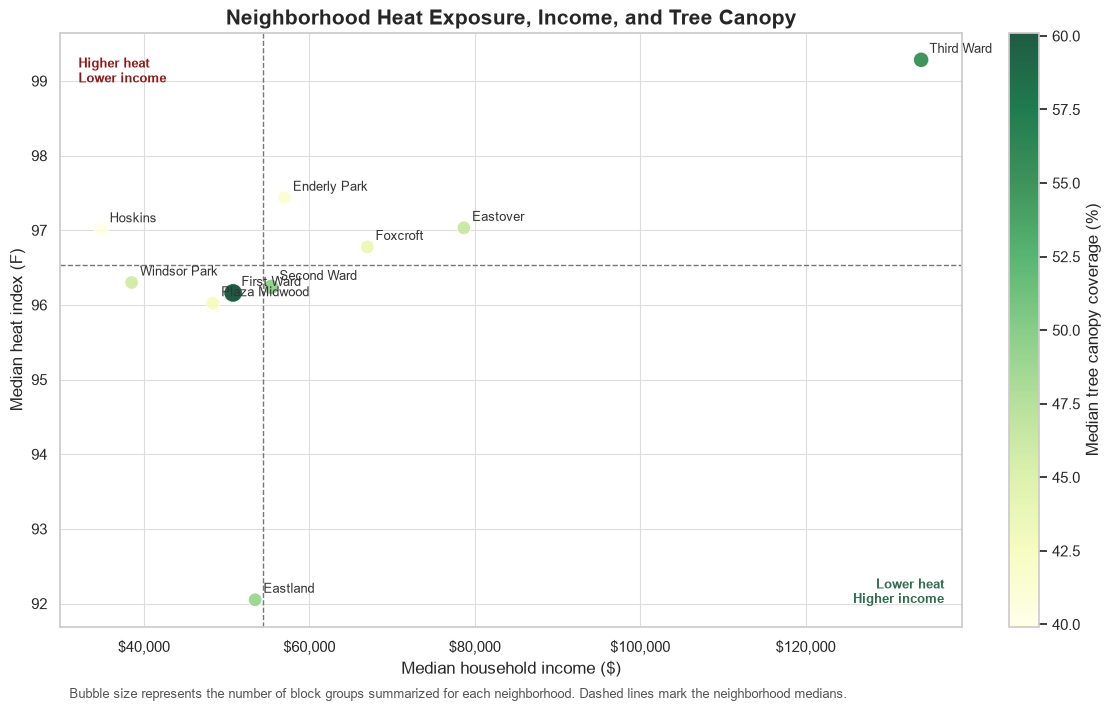

In [59]:
from matplotlib.ticker import StrMethodFormatter

# Neighborhood-level view
neighborhood_plot = nbhd_stats.dropna(
    subset=["median_income", "median_heat", "median_canopy"]
).copy()

income_median = neighborhood_plot["median_income"].median()
heat_median = neighborhood_plot["median_heat"].median()

fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)
point_sizes = 70 + neighborhood_plot["n_block_groups"] * 28
scatter = ax.scatter(
    neighborhood_plot["median_income"],
    neighborhood_plot["median_heat"],
    s=point_sizes,
    c=neighborhood_plot["median_canopy"],
    cmap="YlGn",
    vmin=neighborhood_plot["median_canopy"].min(),
    vmax=neighborhood_plot["median_canopy"].max(),
    alpha=0.88,
    edgecolor="white",
    linewidth=0.8,
)

for _, row in neighborhood_plot.iterrows():
    ax.annotate(
        row["neighborhood_name"],
        (row["median_income"], row["median_heat"]),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=9,
        color="#333333",
    )

ax.axvline(income_median, color="#777777", linestyle="--", linewidth=1)
ax.axhline(heat_median, color="#777777", linestyle="--", linewidth=1)
ax.text(
    0.02,
    0.96,
    "Higher heat\nLower income",
    transform=ax.transAxes,
    va="top",
    fontsize=9,
    color="#8b1a1a",
    fontweight="bold",
)
ax.text(
    0.98,
    0.04,
    "Lower heat\nHigher income",
    transform=ax.transAxes,
    ha="right",
    fontsize=9,
    color="#2d6a4f",
    fontweight="bold",
)

ax.set_title(
    "Neighborhood Heat Exposure, Income, and Tree Canopy",
    fontsize=15,
    fontweight="bold",
)
ax.set_xlabel("Median household income ($)")
ax.set_ylabel("Median heat index (F)")
ax.xaxis.set_major_formatter(StrMethodFormatter("${x:,.0f}"))
ax.grid(color="#dddddd", linewidth=0.8)

colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
colorbar.set_label("Median tree canopy coverage (%)")

ax.text(
    0.01,
    -0.12,
    "Bubble size represents the number of block groups summarized for each neighborhood. "
    "Dashed lines mark the neighborhood medians.",
    transform=ax.transAxes,
    fontsize=9,
    color="#555555",
)

OUTPUT_DIR = PROJECT_DIR / "notebooks" / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUTPUT_DIR / "neighborhood_heat_income_canopy.png", dpi=300, bbox_inches="tight")
plt.show()

In [60]:
import folium

charlotte_center = [35.2271, -80.8431]
m = folium.Map(
    location=charlotte_center,
    zoom_start=11,
    tiles="CartoDB positron",
    control_scale=True,
)

# Format the values shown when a user hovers over a block group.
gdf_full["income_label"] = gdf_full["median_income"].apply(
    lambda value: f"${value:,.0f}" if pd.notna(value) else "No data"
)
gdf_full["canopy_label"] = gdf_full["canopy_pct_2022"].apply(
    lambda value: f"{value:.1f}%" if pd.notna(value) else "No data"
)
gdf_full["heat_label"] = gdf_full["mean_heat_index"].apply(
    lambda value: f"{value:.1f} F" if pd.notna(value) else "Not sampled"
)
gdf_full["change_label"] = gdf_full["canopy_change_pct"].apply(
    lambda value: f"{value:+.1f}%" if pd.notna(value) else "No data"
)

# Put the research question directly on the map.
title_html = """
<div style="
    position: fixed;
    top: 14px;
    left: 50%;
    transform: translateX(-50%);
    z-index: 1000;
    background: rgba(255, 255, 255, 0.96);
    border: 1px solid #b8b8b8;
    border-radius: 5px;
    padding: 10px 16px;
    width: min(680px, 82vw);
    text-align: center;
    font-family: Arial, sans-serif;
    box-shadow: 0 1px 5px rgba(0, 0, 0, 0.18);
">
    <div style="font-size: 17px; font-weight: 700; color: #222;">
        Charlotte Urban Heat, Tree Canopy, and Income
    </div>
    <div style="font-size: 12px; line-height: 1.35; color: #444; margin-top: 4px;">
        Does lower canopy correspond to higher heat, and are the hottest block groups lower-income?
    </div>
</div>
"""
m.get_root().html.add_child(folium.Element(title_html))

# Hover values keep all three research variables visible at once.
tooltip_bg = folium.GeoJsonTooltip(
    fields=[
        "neighborhood_name",
        "canopy_label",
        "heat_label",
        "income_label",
        "change_label",
    ],
    aliases=[
        "Neighborhood:",
        "Tree canopy (2022):",
        "Mean heat index:",
        "Median income:",
        "Canopy change (2018-22):",
    ],
    localize=True,
    sticky=True,
    style=(
        "background-color: #ffffff; border: 1px solid #999; border-radius: 4px;"
        "font-family: Arial, sans-serif; font-size: 12px; padding: 8px 10px;"
        "box-shadow: 2px 2px 6px rgba(0,0,0,0.15);"
    ),
)

def style_bivariate(feature):
    color = feature["properties"].get("biv_color") or "#d9d9d9"
    return {
        "fillColor": color,
        "color": "#555555",
        "weight": 0.3,
        "fillOpacity": 0.75,
    }


def highlight_bg(feature):
    return {"fillOpacity": 0.95, "weight": 1.5, "color": "#222222"}

# Main summary layer: canopy and heat together in the bivariate palette.
folium.GeoJson(
    gdf_full,
    name="Canopy x heat (bivariate)",
    style_function=style_bivariate,
    highlight_function=highlight_bg,
    tooltip=tooltip_bg,
    show=True,
).add_to(m)

# Toggleable single-variable layers make each relationship easy to inspect.
folium.Choropleth(
    geo_data=gdf_full,
    name="Heat exposure",
    data=gdf_full,
    columns=["GEOID_bg", "mean_heat_index"],
    key_on="feature.properties.GEOID_bg",
    fill_color="YlOrRd",
    fill_opacity=0.75,
    line_opacity=0.2,
    nan_fill_color="#d9d9d9",
    nan_fill_opacity=0.35,
    legend_name="Mean heat index (F)",
    show=False,
).add_to(m)

folium.Choropleth(
    geo_data=gdf_full,
    name="Median income",
    data=gdf_full,
    columns=["GEOID_bg", "median_income"],
    key_on="feature.properties.GEOID_bg",
    fill_color="YlGnBu",
    fill_opacity=0.75,
    line_opacity=0.2,
    nan_fill_color="#d9d9d9",
    nan_fill_opacity=0.35,
    legend_name="Median household income ($)",
    show=False,
).add_to(m)

folium.Choropleth(
    geo_data=gdf_full,
    name="Tree canopy",
    data=gdf_full,
    columns=["GEOID_bg", "canopy_pct_2022"],
    key_on="feature.properties.GEOID_bg",
    fill_color="Greens",
    fill_opacity=0.75,
    line_opacity=0.2,
    nan_fill_color="#d9d9d9",
    nan_fill_opacity=0.35,
    legend_name="Tree canopy coverage (%)",
    show=False,
).add_to(m)

c:\Users\Fiorella\OneDrive\VSCODE PROJECTS\Projects\DTSC 2\Personal Project Part 1\.venv\Lib\site-packages\folium\raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [61]:
if len(named) > 0:
    def nbhd_style(feature):
        return {'fillColor': '#00000000', 'color': '#1a1a2e', 'weight': 2.5,
                'fillOpacity': 0, 'dashArray': '5 3'}

    def nbhd_highlight(feature):
        return {'color': '#ff6b35', 'weight': 4}

    for _, row in neighborhood_polys.iterrows():
        canopy_str = f"{row['median_canopy']:.1f}%" if pd.notna(row['median_canopy']) else 'No data'
        heat_str   = f"{row['median_heat']:.1f} F" if pd.notna(row['median_heat']) else 'Not sampled'
        income_str = f"${row['median_income']:,.0f}" if pd.notna(row['median_income']) else 'No data'
        popup_html = (
            '<div style="font-family:sans-serif;font-size:13px;min-width:180px;">'
            f'<b style="font-size:14px;">{row["neighborhood_name"]}</b><br>'
            '<hr style="margin:4px 0;border-color:#eee;">'
            f'<b>Median tree canopy:</b> {canopy_str}<br>'
            f'<b>Median heat index:</b> {heat_str}<br>'
            f'<b>Median income:</b> {income_str}<br>'
            f'<span style="color:#888;font-size:10px;">{int(row["n_block_groups"])} block groups</span>'
            '</div>'
        )
        folium.GeoJson(
            row['geometry'].__geo_interface__,
            style_function=nbhd_style,
            highlight_function=nbhd_highlight,
            popup=folium.Popup(popup_html, max_width=250),
            tooltip=folium.Tooltip(
                row['neighborhood_name'],
                style='font-family:sans-serif;font-weight:bold;font-size:13px;'
            ),
        ).add_to(m)

In [62]:
legend_html = '''
<div style="position:fixed;bottom:40px;left:40px;z-index:1000;background:white;
border:1px solid #ccc;border-radius:6px;padding:12px 14px;font-family:sans-serif;
font-size:11px;box-shadow:2px 2px 8px rgba(0,0,0,0.2);min-width:210px;">
  <b style="font-size:12px;">Canopy x Heat</b>
  <table style="margin-top:6px;border-collapse:collapse;">
    <tr>
      <td></td>
      <td style="font-size:10px;text-align:center;color:#555;padding:0 3px;">High heat</td>
      <td style="font-size:10px;text-align:center;color:#555;padding:0 3px;">Mid heat</td>
      <td style="font-size:10px;text-align:center;color:#555;padding:0 3px;">Low heat</td>
    </tr>
    <tr>
      <td style="font-size:10px;color:#555;padding-right:4px;">Low canopy</td>
      <td><div style="width:22px;height:22px;background:#8b1a1a;border-radius:2px;"></div></td>
      <td><div style="width:22px;height:22px;background:#c0392b;border-radius:2px;"></div></td>
      <td><div style="width:22px;height:22px;background:#e57373;border-radius:2px;"></div></td>
    </tr>
    <tr>
      <td style="font-size:10px;color:#555;padding-right:4px;">Mid canopy</td>
      <td><div style="width:22px;height:22px;background:#7b5ea7;border-radius:2px;"></div></td>
      <td><div style="width:22px;height:22px;background:#a89cc8;border-radius:2px;"></div></td>
      <td><div style="width:22px;height:22px;background:#c8b4e3;border-radius:2px;"></div></td>
    </tr>
    <tr>
      <td style="font-size:10px;color:#555;padding-right:4px;">High canopy</td>
      <td><div style="width:22px;height:22px;background:#2d6a4f;border-radius:2px;"></div></td>
      <td><div style="width:22px;height:22px;background:#52b788;border-radius:2px;"></div></td>
      <td><div style="width:22px;height:22px;background:#b7e4c7;border-radius:2px;"></div></td>
    </tr>
  </table>
  <div style="margin-top:6px;display:flex;align-items:center;gap:5px;">
    <div style="width:18px;height:18px;background:#d9d9d9;border-radius:2px;"></div>
    <span>Not sampled (CHARP traverse)</span>
  </div>
  <div style="margin-top:4px;display:flex;align-items:center;gap:5px;">
    <div style="width:22px;border-top:2.5px dashed #1a1a2e;"></div>
    <span>Named neighborhood boundary</span>
  </div>
  <div style="margin-top:4px;color:#888;font-size:10px;">Click neighborhood boundary for stats</div>
</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl(collapsed=False).add_to(m)

output_dir = Path('output')
output_dir.mkdir(parents=True, exist_ok=True)
map_file = output_dir / 'charlotte_heat_equity_map.html'
m.save(map_file)
print(f'Map saved to {map_file}')

Map saved to output\charlotte_heat_equity_map.html


In [63]:
%history

import pandas as pd
import geopandas as gpd
import numpy as np
import folium
from pathlib import Path

processed_file = Path(
    r"C:\Users\Fiorella\OneDrive\VSCODE PROJECTS\Projects\DTSC 2\Personal Project Part 1\notebooks\data\processed\charlotte_analysis.geojson"
)
gdf = gpd.read_file(processed_file, engine="pyogrio").to_crs(epsg=4326)
gdf_full = gdf.copy()
gdf_heat = gdf[gdf["mean_heat_index"].notna()].copy()
print(f"Full dataset: {len(gdf_full)} block groups")
print(f"Heat subset:  {len(gdf_heat)} block groups")
canopy_tertiles = gdf_heat['canopy_pct_2022'].quantile([0.333, 0.667]).values
heat_tertiles   = gdf_heat['mean_heat_index'].quantile([0.333, 0.667]).values

print(f'Canopy tertile cuts: {canopy_tertiles[0]:.1f}%, {canopy_tertiles[1]:.1f}%')
print(f'Heat tertile cuts:   {heat_tertiles[0]:.1f}F, {heat_tertiles[1]:.1f}F')

def canopy_tier(val):
    if pd.isna(val): return None
    if val <= canopy_tertiles[0]: return 'low'
    if val <= canopy_tertiles[1]: return 'mid'
    r